# (23) Grad Fixed Point Analysis

**Project: `_PoissonGradEstim`**

In [1]:
# HIDE CODE


project_name = '_PoissonGradEstim'


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

# GitHub 
from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

# dtype = torch.bfloat16 # half the size of float32
dtype = torch.float32

print(f"device: {device}, dtype: {dtype}  ———  host: {os.uname().nodename}")

device: cuda:0, dtype: torch.float32  ———  host: mach

In [3]:
import importlib


def purge_modules_from_path(root_dir: str) -> None:
    root_dir = os.path.abspath(root_dir) + os.sep
    for name, mod in list(sys.modules.items()):
        f = getattr(mod, "__file__", None)
        if f is None:
            continue
        try:
            if os.path.abspath(f).startswith(root_dir):
                del sys.modules[name]
        except Exception:
            # Defensive: some modules have weird __file__ values
            pass

# --- 1) Import from _PoissonGradEstim ---
pge_path = pjoin(os.environ['HOME'], 'Dropbox/git', project_name)
sys.path.insert(0, pge_path)
try:
    from analysis.grad_analysis import *
    from analysis.dist_analysis import *
    from analysis.plotting_functions import *
finally:
    sys.path[:] = [p for p in sys.path if p != pge_path]

# Important: purge anything imported from that repo (including a "base" package, if present)
purge_modules_from_path(pge_path)
importlib.invalidate_caches()

# --- 2) Import from PoissonVAE ---
pvae_path = pjoin(os.environ["HOME"], "Dropbox/git", "PoissonVAE")
sys.path.insert(0, pvae_path)

from base.utils_model import load_model


## Make fig dir

In [4]:
fig_dir = fig_base_dir / f'{project_name}_figs-({now()})'
fig_dir.mkdir(exist_ok=True)

os.listdir(str(fig_dir))

[]

## Load model

In [5]:
model = 'poisson_uniform_c(-4)_vH16_z-512_k-32_fp_nrm-none_<conv|lin>'
fit = 'indic-sigmoid_mc_b1000-ep3000-lr(0.001)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,16:24)'

tr, meta = load_model(model, fit, device=device)
print(meta)

{
    'timestamp': '2026_01_06,16:24',
    'checkpoint': 3000,
    'global_step': 309000,
    'root': 
'/home/hadi/Projects/PoissonVAE/models/poisson_uniform_c(-4)_vH16_z-512_k-32_fp_nrm-none_<conv|lin>/indic-sigmoid_m
c_b1000-ep3000-lr(0.001)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,16:24)',
    'file': 'PoissonVAE+TrainerVAE-3000_(2026_01_06,21:47).pt'
}

## Gradient analysis

In [6]:
phi = tr.model.fc_dec.get_weight().data
phi = phi.to(device=device, dtype=dtype)
phi.shape

torch.Size([256, 512])

In [7]:
batch_size = 90

x = tr.dl_vld.dataset.tensors[0].flatten(start_dim=1)
var = tonp(torch.var(x, dim=1))
x = x[np.argsort(var)]

x = x[-batch_size:]

x = x.to(device=device, dtype=dtype)

x.shape

torch.Size([90, 256])

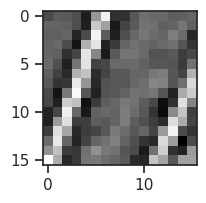

In [8]:
imshow(x[-50].reshape(16, 16), cmap='Greys_r')
plt.show()

In [43]:
# --- Reuse Exact Loss Logic ---
def exact_loss_grad_hessian(log_rate, phi, x):
    """
    Computes analytical loss and exact gradient w.r.t log_rate.
    Using the functions we verified earlier.
    """
    if log_rate.dim() == 1: log_rate = log_rate.unsqueeze(0)
    if x.dim() == 1: x = x.unsqueeze(0)

    lam = torch.exp(log_rate)
    gram_mat = phi.T @ phi
    recon = x - (lam @ phi.T)
    d = torch.diagonal(gram_mat)

    # Gradient
    term1 = 2 * (lam @ gram_mat)
    term2 = 2 * (x @ phi)
    grad_lambda = term1 - term2 + d
    grad_log = lam * grad_lambda

    # Loss (for contours)
    mse_term = (recon ** 2).sum(dim=1)
    var_term = (lam * d).sum(dim=1)
    loss = mse_term + var_term

    return loss, grad_log


def get_expected_gradients(log_rate_grid, phi, x, tau, method, n_samples=2000):
    """
    Estimates E[Gradient] via MC sampling at every point in the grid.
    """
    # Flatten grid for batch processing
    B, K = log_rate_grid.shape
    
    # Expand for MC samples: (N, B, K)
    log_rate_expanded = log_rate_grid.unsqueeze(0).expand(n_samples, B, K).clone()
    log_rate_expanded.requires_grad_(True)
    log_rate_flat = log_rate_expanded.reshape(n_samples * B, K)
    
    # Sample
    dist = Poisson(
        log_rate=log_rate_flat,
        temp=tau,
        indicator_approx=method,
        n_exp='infer'
    )
    z_flat = dist.rsample()
    z = z_flat.reshape(n_samples, B, K)
    
    # Compute Loss & Grad
    x_recon = z @ phi.T
    losses = ((x.unsqueeze(0) - x_recon) ** 2).sum(dim=(1, 2))
    
    grads = torch.autograd.grad(losses.sum(), log_rate_expanded)[0]
    
    # Return Mean Gradient (The Vector Field)
    return grads.mean(dim=0).detach()


def run_vector_field_analysis():
    # 1. Setup Toy Problem (2D)
    # Target Rate = [10, 10]
    # We want the optimum to be at (10, 10).
    # Simple Identity Decoder: Phi = I
    target_rate = torch.tensor([10.0, 10.0])
    x_target = target_rate # If Phi=I, x=Target
    phi = torch.eye(2)

    # 2. Define Grid
    # Sweep rates from 5 to 15
    grid_size = 15
    r_min, r_max = 6.0, 14.0
    r_vals = torch.linspace(r_min, r_max, grid_size)
    r1, r2 = torch.meshgrid(r_vals, r_vals, indexing='ij')
    
    rates_grid = torch.stack([r1.flatten(), r2.flatten()], dim=1) # (B, 2)
    log_rates_grid = rates_grid.log().requires_grad_(True)
    
    # 3. Compute Fields
    print("Computing Ground Truth Field...")
    loss_vals, true_grads = exact_loss_grad_hessian(log_rates_grid, phi, x_target)
    
    temp = 1.0 # The "Liar" regime
    print(f"Computing Sigmoid Field (T={temp})...")
    sigmoid_grads = get_expected_gradients(log_rates_grid, phi, x_target, temp, 'sigmoid')
    
    print(f"Computing Cubic Field (T={temp})...")
    cubic_grads = get_expected_gradients(log_rates_grid, phi, x_target, temp, 'cubic')
    
    # 4. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    
    # Reshape for plotting
    X = r1.numpy()
    Y = r2.numpy()
    Loss = loss_vals.detach().numpy().reshape(grid_size, grid_size)
    
    # Helper to plot quiver
    def plot_field(ax, grads, title, color):
        U = tonp(grads[:, 0]).reshape(grid_size, grid_size)
        V = tonp(grads[:, 1]).reshape(grid_size, grid_size)
        
        # Plot Contours (Loss Landscape)
        ax.contour(X, Y, Loss, levels=15, colors='gray', alpha=0.4, linewidths=1)
        ax.plot(10, 10, 'r*', markersize=15, label='Optimum')
        
        # Plot Vectors
        # We normalize scale slightly to make it readable, but keep relative magnitudes
        
        arrow_mult = 0.3  # >1 longer, <1 shorter

        ax.quiver(
            X, Y, -U, -V,
            color=color,
            angles="xy",
            scale_units="xy",
            scale=15 / arrow_mult,
            width=0.005,
        )
        
        ax.set_title(title, fontsize=14)
        ax.set_xlabel(r"Rate $\lambda_1$")
        ax.set_ylabel(r"Rate $\lambda_2$")
        ax.grid(True, alpha=0.2)
        ax.set_xlim(r_min, r_max)
        ax.set_ylim(r_min, r_max)

    plot_field(axes[0], true_grads, "Ground Truth Gradient", 'black')
    plot_field(axes[1], sigmoid_grads, f"Sigmoid Expected Grad (T={temp})", 'tab:blue')
    plot_field(axes[2], cubic_grads, f"Cubic Expected Grad (T={temp})", 'tab:orange')
    
    plt.suptitle(f"Vector Field Analysis @ Target=10.0, Temp={temp}\n(Arrows show DESCENT direction)", fontsize=16)

    return fig

Computing Ground Truth Field...

Computing Sigmoid Field (T=1.0)...

Computing Cubic Field (T=1.0)...

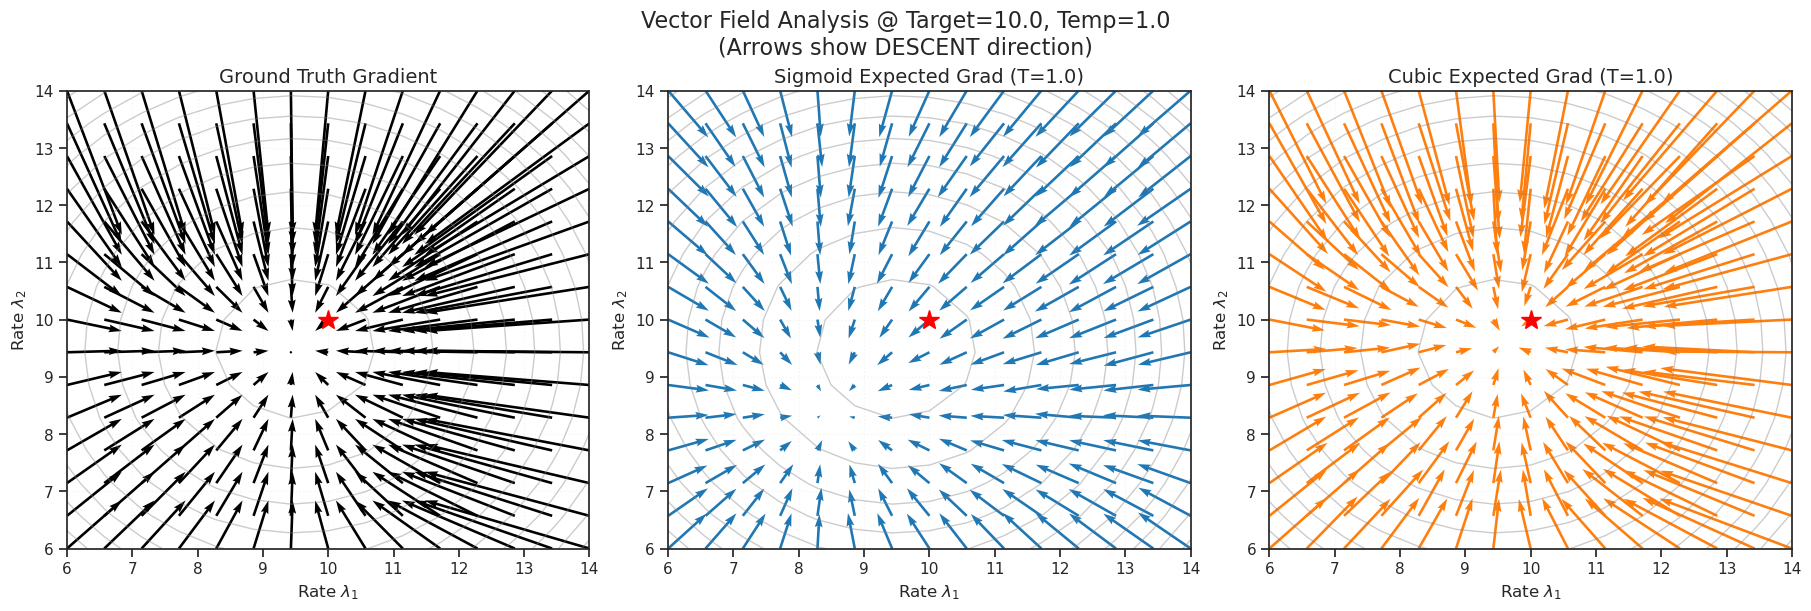

In [44]:
fig = run_vector_field_analysis()
fig

## Surrogate = bad

In [20]:
def run_fixed_point_analysis(n_samples=50000):
    """
    Sweeps firing rates to find where the gradient actually crosses zero.
    Target Rate = 10.0.
    """
    target_k = 10.0
    # Sweep rates around the target
    rates = [6.0, 8.0, 9.0, 9.5, 10.0, 10.5, 11.0, 12.0, 14.0]
    
    # We choose a high temp to exaggerate the "Ghost" effect for the Jab
    tau = 1.0
    
    results = []
    
    print(f"Running Fixed Point Analysis (Target={target_k}, Temp={tau})...")
    
    for r in rates:
        lambda_val = torch.ones(n_samples) * r
        log_rate = lambda_val.log().detach().clone().requires_grad_(True)
        
        # --- 1. EAT Cubic (Relaxed Fwd / Relaxed Bwd) ---
        # "Our Method"
        dist = Poisson(log_rate=log_rate, temp=tau, indicator_approx='cubic')
        z_soft = dist.rsample()
        loss = 0.5 * ((target_k - z_soft)**2).sum() # Soft Loss
        grad = torch.autograd.grad(loss, log_rate)[0]
        results.append({
            'Rate': r,
            'Gradient': grad.mean().item(),
            'Method': 'EAT (Cubic)'
        })

        # --- 2. SNN Surrogate (Hard Fwd / Sigmoid Bwd) ---
        # "Their Method" - Coupled noise
        # Forward: True Poisson (Hard). Backward: Sigmoid (Soft).
        log_rate.grad = None # Reset
        
        # We manually construct the coupled surrogate
        # 1. Sample exponential times (shared source of randomness)
        rate = torch.exp(log_rate)
        n_exp = dist.n_exp # Reuse from previous or recompute
        exp_dist = torch.distributions.Exponential(rate)
        times = torch.cumsum(exp_dist.rsample((n_exp,)), dim=0)
        
        # 2. Hard Forward (True Counts)
        z_hard = (times < 1.0).sum(dim=0).float()
        
        # 3. Soft Backward (Sigmoid Ghosts)
        logits = (1 - times) / tau
        z_soft_sigmoid = torch.sigmoid(logits).sum(dim=0)
        
        # 4. Surrogate Pass: z_surr = z_hard + (z_soft - z_soft.detach())
        z_surr = z_hard + (z_soft_sigmoid - z_soft_sigmoid.detach())
        
        loss = 0.5 * ((target_k - z_surr)**2).sum() # Hard Loss (what they care about)
        grad = torch.autograd.grad(loss, log_rate)[0]
        
        results.append({
            'Rate': r,
            'Gradient': grad.mean().item(),
            'Method': 'SNN Surrogate (Sigmoid)'
        })
    return pd.DataFrame(results)


def plot_fixed_point(df):
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(data=df, x='Rate', y='Gradient', hue='Method', marker='o')
    
    # Add visual guides
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.axvline(10, color='green', linestyle=':', label='True Target (10)')
    
    plt.title(f"Optimization Fixed Point Analysis (Temp=1.0)")
    plt.ylabel("Mean Gradient (Positive = Decrease Rate)")
    plt.xlabel("Current Firing Rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gcf()
    plt.show()
    
    return fig

In [21]:
df4 = run_fixed_point_analysis(n_samples=100_000)

Running Fixed Point Analysis (Target=10.0, Temp=1.0)...

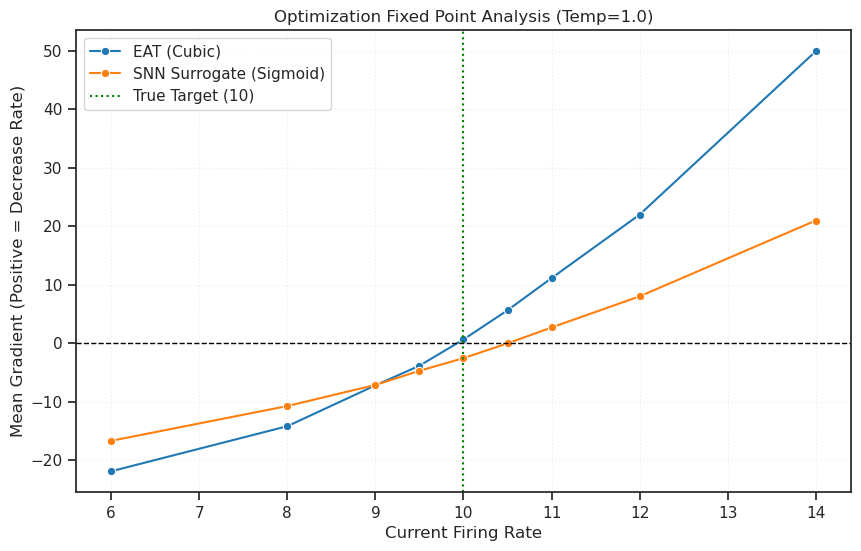

In [22]:
fgi = plot_fixed_point(df4)